# Long term

In [1]:
import numpy as np
import pandas as pd
from math import radians, cos, sin, asin, sqrt
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets
from IPython.display import display, clear_output

In [2]:
%load_ext autoreload

In [3]:
#Run this to reload the python file
%autoreload 2
from utils import *

## Import data

In [4]:
# read the file with the pcp information from GPM and IMN
imn_df = pd.read_csv('./Data/harmonized/unif_IMN.csv')
gpm_df = pd.read_csv('./Data/harmonized/unif_GPM.csv')

In [ ]:
meta = pd.read_csv('./Data/metadata/IMN_stations_rev.csv')

In [ ]:
gpm_coord = pd.read_csv('./Data/metadata/gpm_coords.csv')

## Pre process

In [5]:
# check the len of the dfs
print(len(imn_df))
print(len(gpm_df))

192840
192840


In [6]:
# assigning 'date' as index
imn_df = convert_index(imn_df, 'date')
gpm_df = convert_index(gpm_df, 'date')

In [7]:
# match gpm_df dates with imn_df
imn_df = imn_df['2001-01-01 00:00:00':'2022-12-31 23:00:00']
gpm_df = gpm_df['2001-01-01 00:00:00':'2022-12-31 23:00:00']

## Analysis

In [8]:
temp_resol = {
    '1D': '1 día',
    '7D': '1 semana',
    '1M': '1 mes'
}

### Correlations

In [ ]:
corr_temp = []
for window in temp_resol.keys():
    tmp = corr_accum(imn_df, gpm_df, window)
    result_dict = {
        'window': window,
        'correlation': tmp.get('correlation')
    }
    corr_temp.append(result_dict)

In [ ]:
df = pd.DataFrame()
df['1D'] = corr_temp[0]['correlation']
df['7D'] = corr_temp[1]['correlation']
df['1M'] = corr_temp[2]['correlation']

In [ ]:
df = df.reset_index()
df.rename(columns={'index': 'numero'}, inplace=True)

In [ ]:
df['numero'] = df['numero'].astype(float)

### Distance between points

In [ ]:
#gpm_coord['distance'] = gpm_coord.apply(lambda row: haversine(row['lat'],
#                                                              row['lon'],
#                                                              meta.loc[meta['station_number'] == row['number'], 'lat'].iloc[0],
#                                                              meta.loc[meta['station_number'] == row['number'], 'lon'].iloc[0]),
#                                        axis=1)

In [ ]:
#gpm_coord.to_csv('./Data/metadata/gpm_coords.csv')

In [ ]:
#tmp = meta.merge(gpm_coord, left_on='Número', right_on='number')
#tmp = tmp.merge(df, left_on='Número', right_on='numero')
#tmp = tmp.drop(columns=['Unnamed: 0.1_x', 'Unnamed: 0_x', 'station_number', 'Unnamed: 0.1_y','Unnamed: 0_y', 'number', 'numero'])
#tmp.to_csv('./Data/metadata/long_term_v07.csv')

In [9]:
meta_df = pd.read_csv('./Data/metadata/long_term_v07.csv')

### Differences between accumulated

In [ ]:
# List to store dictionaries
result_list = []

# Loop through columns and append results to the list
for number in imn_df.columns:
    result_dict = diff_accum(imn_df, gpm_df, number)
    result_list.append(result_dict)

# Convert the list of dictionaries into a DataFrame
accumulated_diff = pd.DataFrame(result_list)

In [ ]:
#accumulated_diff['number'] = accumulated_diff['number'].astype(float)

In [ ]:
meta_df = meta_df.merge(accumulated_diff, left_on='Número', right_on='number')

In [ ]:
meta_df = meta_df.drop(columns='number')

In [10]:
meta_df.to_csv('./Data/metadata/long_term_v07.csv')

In [9]:
meta_df

,Unnamed: 0.1,Unnamed: 0,Número,Nombre,Latitud Norte,Longitud Oeste,Altitud (m.s.n.m.),Inicio,Fin,lat_x,lon_x,percentage,lat_y,lon_y,distance,1D,7D,1M,diff_accum,percentage_diff
0,0,0,69633,"COMANDO LOS CHILES,","11º 01' 54""","84º 42' 42""",40,2000-01-01 00:00:00,2022-12-31 00:00:00,11.031667,-84.711667,8.699440,11.05,-84.75,4.655142,0.575789,0.696305,0.768210,-58216.737777,-60.062248
1,1,1,69679,UPALA,"10º 52' 51""","85º 04' 21""",60,2000-01-01 00:00:00,2022-12-31 00:00:00,10.880833,-85.072500,4.433727,10.85,-85.05,4.219212,0.500601,0.659002,0.738494,-38087.287852,-41.177321
2,2,2,69681,LA REBUSCA,"10º 29' 00""","84º 01' 00""",40,2000-01-01 00:00:00,2022-12-31 00:00:00,10.483333,-84.016667,8.064717,10.45,-84.05,5.199821,0.555233,0.586765,0.551036,-60985.046826,-43.938542
3,3,3,71015,"CANTA GALLO,","10º 29' 48""","83º 40' 28""",20,2000-01-01 00:00:00,2022-12-31 00:00:00,10.496667,-83.674444,9.637523,10.45,-83.65,5.838657,0.576497,0.598189,0.548267,-81308.736212,-49.057520
4,4,4,72157,"FINCA LA CEIBA,","10º 06' 40""","85º 19' 03""",58,2000-01-01 00:00:00,2022-12-31 00:00:00,10.111111,-85.317500,5.487969,10.15,-85.35,5.601124,0.619529,0.783787,0.861710,-55248.537790,-58.876296
5,5,5,73123,"ITCR, CARTAGO","09º 51' 08""","83º 54' 31""",1360,2000-01-01 00:00:00,2022-12-31 00:00:00,9.852222,-83.908611,4.155777,9.85,-83.95,4.542388,0.433235,0.644159,0.827055,-123069.686460,-79.656917
6,6,6,74051,AEROP. LIBERIA OESTE 07,"10º 35' 20,40""","85º 33' 07,70""",89,2000-01-01 00:00:00,2022-12-31 00:00:00,10.589000,-85.552139,1.581622,10.55,-85.55,4.344127,0.645283,0.810700,0.896645,-51702.157980,-59.669974
7,7,7,74053,"SANTA CRUZ,","10º 17' 07""","85º 35' 30""",40,2000-01-01 00:00:00,2022-12-31 00:00:00,10.285278,-85.591667,8.751815,10.25,-85.55,6.015971,0.585661,0.741316,0.808633,-58522.707845,-62.570515
8,8,8,76055,"HDA. MOJICA,","10º 27' 10""","85º 09' 55""",33,2000-01-01 00:00:00,2022-12-31 00:00:00,10.452778,-85.165278,4.035988,10.45,-85.15,1.699420,0.586379,0.753191,0.811973,-62983.867918,-69.249060
9,9,9,81005,"AEROP. LIMON,","09º 57' 44""","83º 01' 29""",5,2000-01-01 00:00:00,2022-12-31 00:00:00,9.962222,-83.024722,4.036507,9.95,-83.05,3.084900,0.682651,0.692933,0.652374,-83623.136377,-53.063384


## Plotting

### Correlations

In [24]:
meta_df['Número']

0     69633
1     69679
2     69681
3     71015
4     72157
5     73123
6     74051
7     74053
8     76055
9     81005
10    84139
11    84141
12    84169
13    84187
14    84191
15    84197
16    98075
17    98087
18    98091
19    98095
Name: Número, dtype: int64

In [25]:
# change the stations order by climate zone
desired_order = [81005, 69681, 71015, 69679, 69633, 74051, 74053, 76055, 72157, 84139, 84141, 84169, 84187, 84191, 84197, 73123, 98091, 98087, 98095, 98075]

meta_df = meta_df.sort_values(by='Número', key=lambda x: x.map({v: i for i, v in enumerate(desired_order)}))


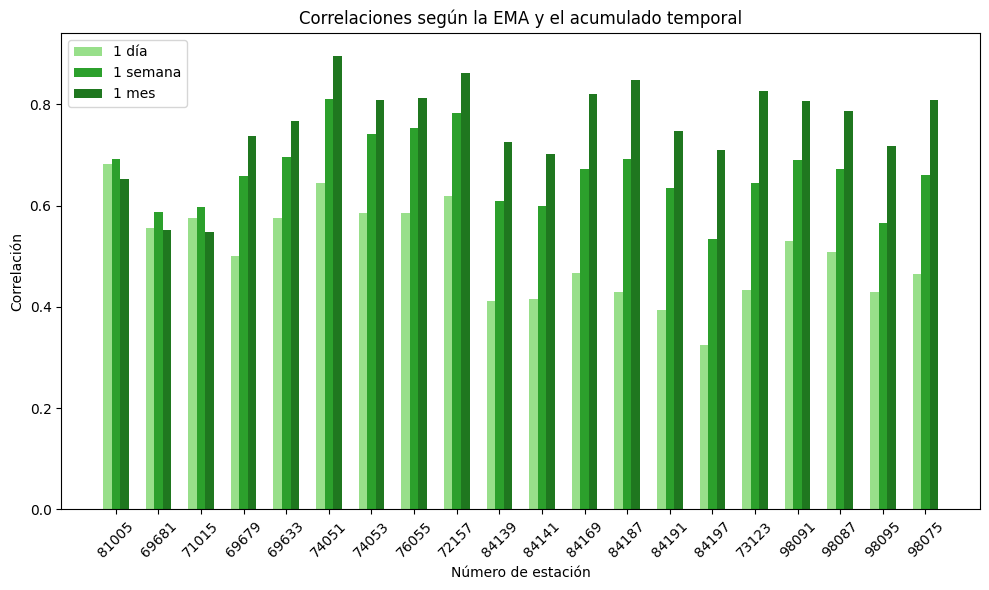

In [32]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

# Bar width can be adjusted based on preference
bar_width = 0.2
bar_positions = np.arange(len(meta_df['Número'].unique()))

# Define colors for each bar
color_1d = '#98df8a'  # Light green
color_7d = '#2ca02c'  # Green
color_1m = '#1f771f'  # Dark green

# Plot each column as a separate bar with assigned colors
ax.bar(bar_positions - bar_width, meta_df['1D'], width=bar_width, label='1 día', color=color_1d)
ax.bar(bar_positions, meta_df['7D'], width=bar_width, label='1 semana', color=color_7d)
ax.bar(bar_positions + bar_width, meta_df['1M'], width=bar_width, label='1 mes', color=color_1m)

# Set labels and title
ax.set_xlabel('Número de estación')
ax.set_ylabel('Correlación')
ax.set_title('Correlaciones según la EMA y el acumulado temporal')
ax.legend()

plt.xticks(bar_positions, meta_df['Número'].unique())
plt.xticks(rotation=45)

plt.tight_layout()

# Show the plot
plt.show()


### Location vs Temporal Accumulated Correlation 

In [12]:
# Create a dropdown widget for selecting the column
column_options = list(temp_resol.keys())
column_dropdown = widgets.Dropdown(
    options=column_options,
    value=column_options[0],
    description='Acumulado:',
    disabled=False
)

In [13]:
# Create an interactive plot
interactive_plot = widgets.interactive(
    scatter_plot,
    df=widgets.fixed(meta_df),
    column=column_dropdown
)

# Display the interactive plot
display(interactive_plot)

interactive(children=(Dropdown(description='Acumulado:', options=('1D', '7D', '1M'), value='1D'), Output()), _…

### Location vs Difference in the accumulated

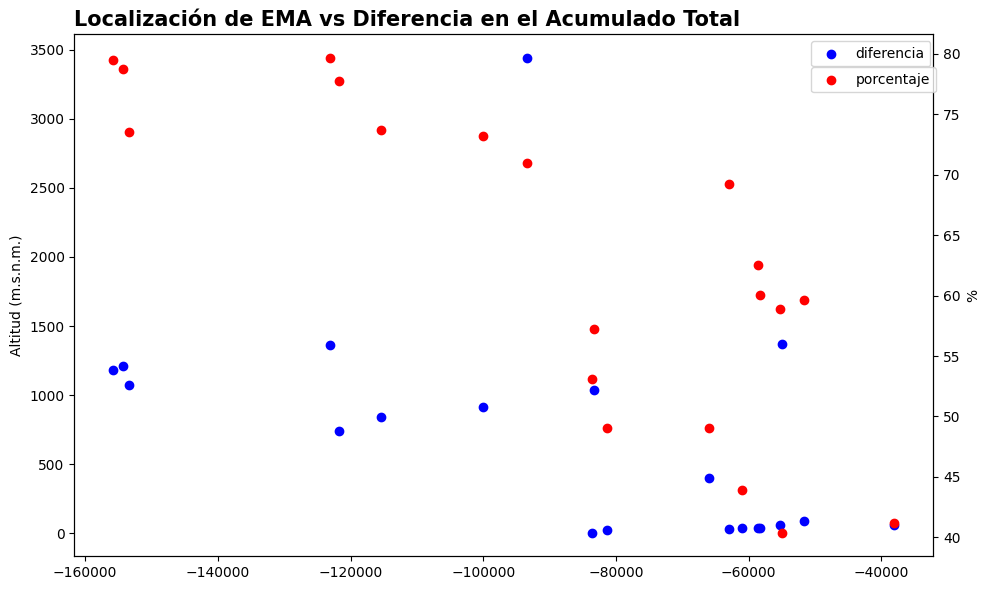

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(meta_df['diff_accum'], meta_df['Altitud (m.s.n.m.)'], label='diferencia', color='blue')
ax.set_ylabel('Altitud (m.s.n.m.)')

twin_axes = ax.twinx()
twin_axes.scatter(meta_df['diff_accum'], (-1)*meta_df['percentage_diff'], label='porcentaje', color='red')
twin_axes.set_ylabel('%')

# Adjust the legend positions
ax.legend(loc='upper left', bbox_to_anchor=(0.85, 1.0))
twin_axes.legend(loc='upper left', bbox_to_anchor=(0.85, 0.95))

ax.set_title(str('Localización de EMA vs Diferencia en el Acumulado Total'), fontweight='bold', fontsize=15, loc='left')
fig.tight_layout()

# Display the plot in the notebook
plt.show()


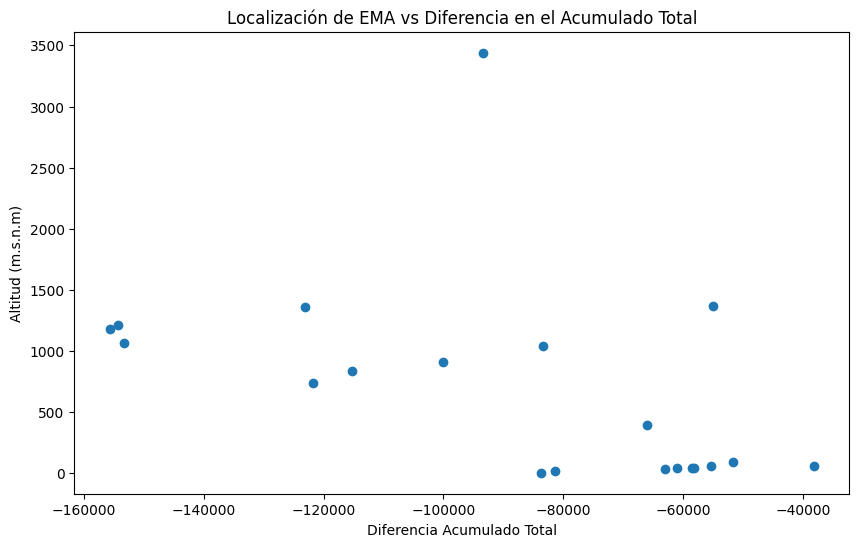

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(meta_df['diff_accum'], meta_df['Altitud (m.s.n.m.)'])
plt.xlabel('Diferencia Acumulado Total')
plt.ylabel('Altitud (m.s.n.m)')
plt.title(f'Localización de EMA vs Diferencia en el Acumulado Total')
plt.show()

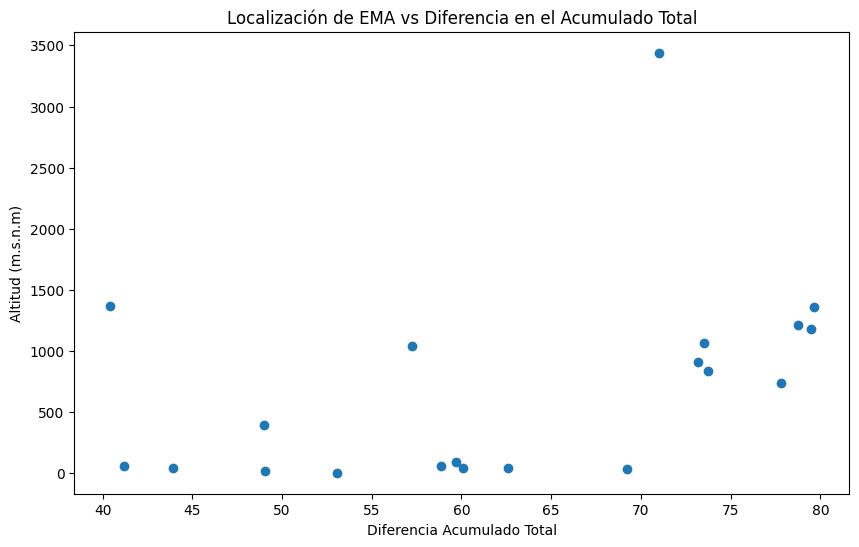

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter((-1)*meta_df['percentage_diff'], meta_df['Altitud (m.s.n.m.)'])
plt.xlabel('Diferencia Acumulado Total')
plt.ylabel('Altitud (m.s.n.m)')
plt.title(f'Localización de EMA vs Diferencia en el Acumulado Total')
plt.show()

### Time Series

In [17]:
# Create a dropdown widget for selecting the column
column_options = list(imn_df.columns)  # Assuming both dataframes have the same columns
column_dropdown = widgets.Dropdown(
    options=column_options,
    value=column_options[0],
    description='Station Number:',
    disabled=False
)

In [18]:
# Create a dropdown widget for selecting resolution
resolution_options = list(temp_resol.keys()) 
resolution_dropdown = widgets.Dropdown(
    options=resolution_options,
    value=resolution_options[0],
    description='Resolution:',
    disabled=False
)

In [22]:
# Create an interactive plot
interactive_plot = widgets.interactive(
    plot_resol,
    df1=widgets.fixed(imn_df),
    df2=widgets.fixed(gpm_df),
    resolution=resolution_dropdown,
    column=column_dropdown
)

# Display the interactive plot
display(interactive_plot)

interactive(children=(Dropdown(description='Resolution:', index=2, options=('1D', '7D', '1M'), value='1M'), Dr…

### Frequency Spectrum

In [20]:
imn_tmp = imn_df.fillna(0)

In [21]:
# Create an interactive plot
interactive_plot = widgets.interactive(
    plot_freq,
    df1=widgets.fixed(imn_tmp),
    df2=widgets.fixed(gpm_df),
    column=column_dropdown
)

# Display the interactive plot
display(interactive_plot)

interactive(children=(Dropdown(description='Station Number:', index=1, options=('84141', '69679', '74051', '73…